In [5]:
import numpy as np
pl = np.load('Unsup_labels/UCF_unsup_labels_original_V2.npy')
pl.shape

(779951,)

In [13]:
xd_res50 = np.load('C:/Users/jplabuser/C2FPL_EVAL/C2FPL/list/gt-XD-R50NL.npy')
xd_res50.shape

(0,)

gt shape  : (2330384,)
pred shape: (2330384,)

[전체 score 통계]
min  : 0.000000
max  : 1.000000
mean : 0.085878
std  : 0.255036

[정상 구간 score 통계]
count: 1792579
min  : 0.000000
max  : 1.000000
mean : 0.063793
std  : 0.221927

[이상 구간 score 통계]
count: 537805
min  : 0.000000
max  : 1.000000
mean : 0.159488
std  : 0.332618

[전체 score 분위수]
50 percentile: 0.000002
75 percentile: 0.001164
90 percentile: 0.204456
95 percentile: 0.944961
99 percentile: 0.999207

[정상 score 분위수]
50 percentile: 0.000000
75 percentile: 0.000286
90 percentile: 0.045437
95 percentile: 0.804692
99 percentile: 0.998281

[이상 score 분위수]
50 percentile: 0.000161
75 percentile: 0.035767
90 percentile: 0.933587
95 percentile: 0.991440
99 percentile: 0.999793


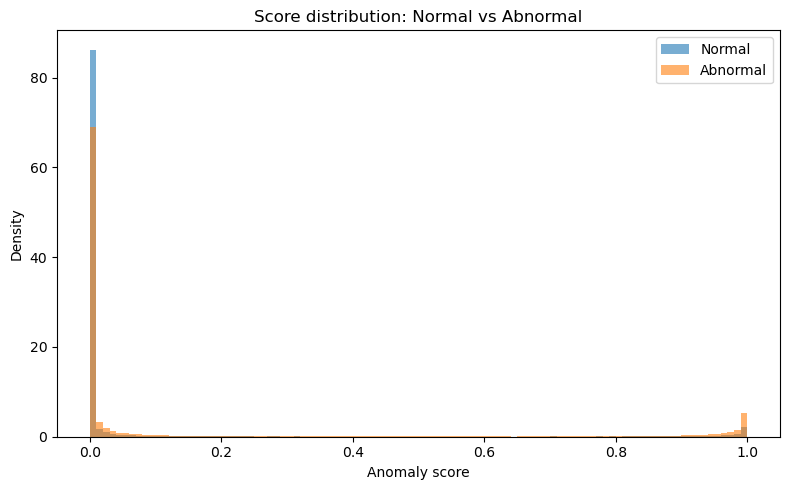

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 파일 경로 수정
gt_path = "list/gt-XD.npy"         # 0/1 ground truth
pred_path = "pred_raw_frame_XD.npy"     # anomaly score

gt = np.load(gt_path)
pred = np.load(pred_path)

print("gt shape  :", gt.shape)
print("pred shape:", pred.shape)

assert gt.shape == pred.shape, "gt와 pred shape이 같아야 합니다."

normal_scores = pred[gt == 0]
abnormal_scores = pred[gt == 1]

print("\n[전체 score 통계]")
print(f"min  : {pred.min():.6f}")
print(f"max  : {pred.max():.6f}")
print(f"mean : {pred.mean():.6f}")
print(f"std  : {pred.std():.6f}")

print("\n[정상 구간 score 통계]")
print(f"count: {len(normal_scores)}")
print(f"min  : {normal_scores.min():.6f}")
print(f"max  : {normal_scores.max():.6f}")
print(f"mean : {normal_scores.mean():.6f}")
print(f"std  : {normal_scores.std():.6f}")

print("\n[이상 구간 score 통계]")
print(f"count: {len(abnormal_scores)}")
print(f"min  : {abnormal_scores.min():.6f}")
print(f"max  : {abnormal_scores.max():.6f}")
print(f"mean : {abnormal_scores.mean():.6f}")
print(f"std  : {abnormal_scores.std():.6f}")

# 분위수도 같이 보면 threshold 감 잡기 좋음
for name, arr in [("전체", pred), ("정상", normal_scores), ("이상", abnormal_scores)]:
    print(f"\n[{name} score 분위수]")
    for q in [50, 75, 90, 95, 99]:
        print(f"{q:>2} percentile: {np.percentile(arr, q):.6f}")

# 히스토그램
plt.figure(figsize=(8, 5))
plt.hist(normal_scores, bins=100, alpha=0.6, label="Normal", density=True)
plt.hist(abnormal_scores, bins=100, alpha=0.6, label="Abnormal", density=True)
plt.xlabel("Anomaly score")
plt.ylabel("Density")
plt.title("Score distribution: Normal vs Abnormal")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
import numpy as np

def compare_nalist(old_nalist_path, new_nalist_path, max_show=60):
    old_nalist = np.load(old_nalist_path)
    new_nalist = np.load(new_nalist_path)

    assert old_nalist.shape == new_nalist.shape, \
        f"shape mismatch: old {old_nalist.shape}, new {new_nalist.shape}"

    old_len = old_nalist[:, 1] - old_nalist[:, 0]
    new_len = new_nalist[:, 1] - new_nalist[:, 0]

    same = (old_len == new_len)
    num_same = int(same.sum())
    num_total = len(same)

    print(f"[NALIST COMPARE]")
    print(f"same T count: {num_same} / {num_total}")
    print(f"different T count: {num_total - num_same}")

    if num_same != num_total:
        diff_idx = np.where(~same)[0]
        print("\nFirst mismatched videos:")
        for i in diff_idx[:max_show]:
            print(f"vid {i}: old T={old_len[i]}, new T={new_len[i]}")
    else:
        print("All video lengths match.")

    return old_len, new_len, same

In [11]:
old_len, new_len, same = compare_nalist(
    old_nalist_path="list/nalist_XD_test.npy",
    new_nalist_path="list/nalist_XD_test_R50NL.npy"
)

[NALIST COMPARE]
same T count: 745 / 800
different T count: 55

First mismatched videos:
vid 1: old T=68, new T=69
vid 7: old T=74, new T=75
vid 12: old T=68, new T=69
vid 27: old T=74, new T=75
vid 55: old T=140, new T=141
vid 59: old T=137, new T=138
vid 69: old T=62, new T=63
vid 73: old T=293, new T=294
vid 78: old T=89, new T=90
vid 80: old T=737, new T=738
vid 81: old T=131, new T=132
vid 97: old T=59, new T=60
vid 118: old T=83, new T=84
vid 123: old T=29, new T=30
vid 124: old T=59, new T=60
vid 126: old T=65, new T=66
vid 127: old T=65, new T=66
vid 128: old T=92, new T=93
vid 129: old T=20, new T=21
vid 131: old T=23, new T=24
vid 157: old T=23, new T=24
vid 188: old T=149, new T=150
vid 189: old T=68, new T=69
vid 209: old T=74, new T=75
vid 231: old T=95, new T=96
vid 247: old T=271, new T=272
vid 324: old T=395, new T=396
vid 336: old T=175, new T=176
vid 341: old T=38, new T=39
vid 413: old T=45, new T=46
vid 426: old T=42, new T=43
vid 428: old T=144, new T=145
vid 437: 

In [14]:
import numpy as np

def load_names(list_path):
    with open(list_path, "r", encoding="utf-8") as f:
        names = [line.strip() for line in f if line.strip()]
    return names

def find_mismatch_videos(old_nalist_path, new_nalist_path, list_path, save_txt_path=None):
    old_nalist = np.load(old_nalist_path)
    new_nalist = np.load(new_nalist_path)
    names = load_names(list_path)

    assert len(old_nalist) == len(new_nalist) == len(names), \
        f"length mismatch: old={len(old_nalist)}, new={len(new_nalist)}, names={len(names)}"

    old_len = old_nalist[:, 1] - old_nalist[:, 0]
    new_len = new_nalist[:, 1] - new_nalist[:, 0]

    mismatches = []
    for i, name in enumerate(names):
        if old_len[i] != new_len[i]:
            mismatches.append({
                "idx": i,
                "name": name,
                "old_T": int(old_len[i]),
                "new_T": int(new_len[i]),
                "diff": int(new_len[i] - old_len[i]),
                "old_start": int(old_nalist[i, 0]),
                "old_end": int(old_nalist[i, 1]),
                "new_start": int(new_nalist[i, 0]),
                "new_end": int(new_nalist[i, 1]),
            })

    print(f"mismatch videos: {len(mismatches)}")
    for x in mismatches[:20]:
        print(x)

    if save_txt_path is not None:
        with open(save_txt_path, "w", encoding="utf-8") as f:
            for x in mismatches:
                f.write(
                    f"{x['idx']}\t{x['name']}\told_T={x['old_T']}\tnew_T={x['new_T']}\tdiff={x['diff']}\n"
                )

    return mismatches

In [15]:
mismatches = find_mismatch_videos(
    old_nalist_path="list/nalist_XD_test.npy",
    new_nalist_path="list/nalist_XD_test_R50NL.npy",
    list_path="list/XD_rgb_test_R50NL.list",
    save_txt_path="mismatch_videos.txt"
)

mismatch videos: 55
{'idx': 1, 'name': 'C:\\Users\\jplabuser\\I3D_Feature_Extraction_resnet\\output_nl_XD\\Bad.Boys.1995__#01-33-51_01-34-37_label_B2-0-0.npy', 'old_T': 68, 'new_T': 69, 'diff': 1, 'old_start': 67, 'old_end': 135, 'new_start': 67, 'new_end': 136}
{'idx': 7, 'name': 'C:\\Users\\jplabuser\\I3D_Feature_Extraction_resnet\\output_nl_XD\\Braveheart.1995__#00-56-30_00-57-20_label_B1-0-0.npy', 'old_T': 74, 'new_T': 75, 'diff': 1, 'old_start': 832, 'old_end': 906, 'new_start': 833, 'new_end': 908}
{'idx': 12, 'name': 'C:\\Users\\jplabuser\\I3D_Feature_Extraction_resnet\\output_nl_XD\\Brick.Mansions.2014__#00-16-26_00-17-12_label_B1-0-0.npy', 'old_T': 68, 'new_T': 69, 'diff': 1, 'old_start': 1649, 'old_end': 1717, 'new_start': 1651, 'new_end': 1720}
{'idx': 27, 'name': 'C:\\Users\\jplabuser\\I3D_Feature_Extraction_resnet\\output_nl_XD\\City.Of.Men.2007__#00-57-37_00-58-27_label_B2-0-0.npy', 'old_T': 74, 'new_T': 75, 'diff': 1, 'old_start': 3403, 'old_end': 3477, 'new_start': 3406

In [16]:
with open(r"C:\Users\jplabuser\Downloads\i3d-features\annotations.txt", "r", encoding="utf-8") as f:
    for _ in range(10):
        print(f.readline().strip())

v=S-7rRLrxnVQ__#1_label_B4-0-0 0 1517 1970 3038
v=u5SF4SlqNDQ__#00-00-00_00-01-00_label_G-0-0 624 912 950 1441
v=u5SF4SlqNDQ__#00-02-39_00-03-41_label_G-0-0 77 1430
v=cEOM18n8fhU__#1_label_G-0-0 2133 2750
v=NnmqkS1e88s__#1_label_B4-0-0 0 1750
v=vaSOMEIe1Bg__#1_label_G-0-0 300 1380
v=ZnFlL84K7HE__#00-27-53_00-34-45_label_B4-0-0 0 9523
v=wVey5JDRf_g__#00-00-00_00-01-20_label_B6-0-0 51 210 273 410 544 720 828 970 1135 1270 1413 1500 1618 1710 1822 1920
v=wVey5JDRf_g__#00-01-30_00-02-41_label_B6-0-0 142 296 447 508 606 710 800 870 1000 1185 1414 1550 1635 1700
v=wVey5JDRf_g__#00-04-09_00-05-06_label_B6-0-0 85 200 352 438 547 690 777 833 918 952 1055 1170 1314 1365


In [5]:

import numpy as np
s = np.load('C:/Users/jplabuser/Downloads/UCF_test_feature/UCF_test_feature/Normal_Videos_641_x264_i3d.npy')
s.shape

(225, 10, 2048)

In [12]:
nalist = np.load("list/nalist.npy")
print("nalist[-1,1] =", int(nalist[-1,1]))
nalist.shape


nalist[-1,1] = 779951


(1609, 2)

In [33]:
import numpy as np
nalist = np.load(r"../../C2FPL/list/nalist_i3d.npy")
pl  = np.load(r"Unsup_labels/UCF_unsup_labels_original_V2.npy")

assert (nalist[:,0] >= 0).all()
assert (nalist[:,1] > nalist[:,0]).all()
assert (nalist[1:,0] == nalist[:-1,1]).all()   # 구간이 딱 이어붙는지


means = []
for a,b in nalist[:50]:
    a=int(a); b=int(b)
    means.append(pl[a:b].mean())
print("first50 mean range:", min(means), max(means))

len_auth = nalist[:,1]-nalist[:,0]
print("len_auth median/mean/min/max:",
      np.median(len_auth), len_auth.mean(), len_auth.min(), len_auth.max())

# 각 비디오 길이 합이 pseudo 길이인지
assert int((nalist[:,1]-nalist[:,0]).sum()) == len(pl)


first50 mean range: 0.0 1.0
len_auth median/mean/min/max: 140.0 484.74269732753265 7 61032


In [29]:
import numpy as np
na = np.load(r"../../C2FPL/list/nalist.npy")
ny = np.load(r"../../C2FPL/list/nalist_i3d.npy")

print("first 10 lengths auth:", (na[:10,1]-na[:10,0]).astype(int))
print("first 10 lengths yours:", (ny[:10,1]-ny[:10,0]).astype(int))
print("same ratio:", ((na[:,1]-na[:,0])==(ny[:,1]-ny[:,0])).mean())


first 10 lengths auth: [ 34 104  58  25  62 161  47  57 147  76]
first 10 lengths yours: [ 171   55  232 1050   60  274   72  526   63   71]
same ratio: 0.0037290242386575512


In [30]:
import numpy as np, os

paths = [line.strip().split()[0] for line in open(r"../../C2FPL/list/ucf-i3d_train_fixed_local.list") if line.strip()]
for i in range(5):
    feat = np.load(paths[i], mmap_mode="r")
    print(i, os.path.basename(paths[i]), "T=", feat.shape[0])


0 Abuse001_x264_i3d.npy T= 171
1 Abuse002_x264_i3d.npy T= 55
2 Abuse003_x264_i3d.npy T= 232
3 Abuse004_x264_i3d.npy T= 1050
4 Abuse005_x264_i3d.npy T= 60


In [4]:
pl_2 = np.load('../../nayoung/Unsup_labels/UCF_hard_label.npy')
pl_2.shape

(779951,)

In [19]:
nalist_2 = np.load("../../C2FPL/list/nalist_i3d.npy")
print("nalist[-1,1] =", int(nalist_2[-1,1]))
#nalist_2.shape

nalist_XD = np.load("list/nalist_XD_test.npy")
print("nalist[-1,1] =", int(nalist_XD[-1,1]))
nalist_XD.shape


nalist[-1,1] = 779951
nalist[-1,1] = 145649


(800, 2)

In [8]:
import numpy as np

nal_auth = np.load(r"../../C2FPL/list/nalist.npy")
nal_yours = np.load(r"../../C2FPL/list/nalist_i3d.npy")

len_auth = nal_auth[:,1] - nal_auth[:,0]
len_yours = nal_yours[:,1] - nal_yours[:,0]

print("num videos:", len(nal_auth), len(nal_yours))
print("same lengths ratio:", (len_auth==len_yours).mean())
print("median auth/yours:", np.median(len_auth), np.median(len_yours))
print("max abs diff:", np.max(np.abs(len_auth - len_yours)))

# 첫 10개 차이 보기
for i in range(10):
    print(i, len_auth[i], len_yours[i], "diff", int(len_yours[i]-len_auth[i]))


num videos: 1609 1609
same lengths ratio: 0.0037290242386575512
median auth/yours: 140.0 140.0
max abs diff: 60992
0 34 171 diff 137
1 104 55 diff -49
2 58 232 diff 174
3 25 1050 diff 1025
4 62 60 diff -2
5 161 274 diff 113
6 47 72 diff 25
7 57 526 diff 469
8 147 63 diff -84
9 76 71 diff -5


In [9]:
import numpy as np, random

paths = [line.strip().split()[0] for line in open("../../C2FPL/list/ucf-i3d_train_fixed_local.list")]
nalist = np.load("../../C2FPL/list/nalist.npy")
total_T = int(nalist[-1,1])
con = np.memmap("../../C2FPL/concat_UCF.npy", dtype="float32", mode="r", shape=(total_T,10,2048))

for i in random.sample(range(len(paths)), 5):
    a,b = map(int, nalist[i])
    feat = np.load(paths[i])  # (T,10,2048)
    d1 = np.max(np.abs(con[a] - feat[0]))
    d2 = np.max(np.abs(con[b-1] - feat[-1]))
    print(i, "T:", feat.shape[0], "diff:", d1, d2)


1055 T: 135 diff: 5.4036703 4.6491394
1506 T: 64 diff: 7.4442024 6.7169404
479 T: 102 diff: 7.2009144 5.873343
120 T: 47 diff: 3.894911 5.759172
1119 T: 113 diff: 7.6965055 7.849602


In [17]:
import os

def vid_key(p):
    base = os.path.basename(p)
    # 예: Normal_XXX_x264.npy 같은 규칙이면 prefix만
    return base.split('.')[0]

auth_list = [line.split()[0].strip() for line in open(r"../../C2FPL/list/ucf-i3d.list", encoding="utf-8") if line.strip()]
your_list = [line.split()[0].strip() for line in open(r"../../C2FPL/list/ucf-i3d_train_fixed_local.list", encoding="utf-8") if line.strip()]

same = sum(vid_key(a)==vid_key(b) for a,b in zip(auth_list, your_list))
print("same order ratio:", same/len(auth_list))

# 틀린 인덱스 몇 개 보기
bad = [i for i,(a,b) in enumerate(zip(auth_list, your_list)) if vid_key(a)!=vid_key(b)]
print("num mismatches:", len(bad), "first mism:", bad[:10])
if bad:
    i = bad[0]
    print("auth:", auth_list[i])
    print("yours:", your_list[i])


same order ratio: 1.0
num mismatches: 0 first mism: []


내가 만든 pseudo 의 이상 비율

In [3]:
p = np.load('../../nayoung/Unsup_labels/UCF_hard_label.npy')  # np array
print("pos ratio:", p.mean(), "min/max:", p.min(), p.max())

pos ratio: 0.05977939639797885 min/max: 0 1


In [17]:
import numpy as np, os, random

na = np.load(r"../../C2FPL/list/nalist.npy")
len_auth = (na[:,1]-na[:,0]).astype(int)

paths = [line.strip().split()[0] for line in open(r"../../C2FPL/list/ucf-i3d_train_fixed_local.list") if line.strip()]

ratios=[]
for i in random.sample(range(len(paths)), 50):
    T = np.load(paths[i], mmap_mode="r").shape[0]
    ratios.append(T / max(1,len_auth[i]))
    
print("ratio median/min/max:", np.median(ratios), min(ratios), max(ratios))


ratio median/min/max: 0.8338755980861243 0.0006553938917289291 81.62068965517241


In [1]:
import numpy as np

paths = [line.strip().split()[0] for line in open("../../C2FPL/list/ucf-i3d_train_fixed_local.list") if line.strip()]
ny = np.load("../../C2FPL/list/nalist_i3d.npy")
ly = (ny[:,1]-ny[:,0]).astype(int)

bad = []
for i in range(len(paths)):
    T = np.load(paths[i], mmap_mode="r").shape[0]
    if T != ly[i]:
        bad.append((i, T, ly[i], paths[i]))

print("mismatch count:", len(bad))
print("first 10 mismatches:", bad[:10])

mismatch count: 0
first 10 mismatches: []


In [5]:
import numpy as np
na = np.load("../../C2FPL/list/nalist.npy")
ny = np.load("../../C2FPL/list/nalist_i3d.npy")
la = (na[:,1]-na[:,0]).astype(int)
ly = (ny[:,1]-ny[:,0]).astype(int)

# 각 길이의 등장 횟수
ua, ca = np.unique(la, return_counts=True)
unique_lengths = set(ua[ca==1])

idx = [i for i in range(len(ly)) if ly[i] in unique_lengths]
print("num uniquely-identifiable videos:", len(idx))

# 몇 개만 찍어서 "이 비디오는 저자 쪽에서 몇 번째였나" 확인
pos_in_auth = {L: int(np.where(la==L)[0][0]) for L in unique_lengths}
for i in idx[:20]:
    L = ly[i]
    print("your idx", i, "len", L, "auth idx", pos_in_auth[L])


num uniquely-identifiable videos: 285
your idx 3 len 1050 auth idx 802
your idx 7 len 526 auth idx 806
your idx 32 len 166 auth idx 831
your idx 36 len 884 auth idx 835
your idx 39 len 1780 auth idx 838
your idx 42 len 318 auth idx 841
your idx 47 len 304 auth idx 846
your idx 49 len 191 auth idx 848
your idx 53 len 400 auth idx 852
your idx 57 len 1011 auth idx 856
your idx 61 len 662 auth idx 860
your idx 63 len 153 auth idx 862
your idx 65 len 184 auth idx 864
your idx 70 len 406 auth idx 869
your idx 73 len 486 auth idx 872
your idx 76 len 485 auth idx 875
your idx 77 len 727 auth idx 876
your idx 78 len 387 auth idx 877
your idx 88 len 3942 auth idx 887
your idx 90 len 738 auth idx 889


In [6]:
import os

auth_list = [line.split()[0].strip() for line in open(r"../../C2FPL/list/ucf-i3d.list", encoding="utf-8") if line.strip()]
your_list = [line.split()[0].strip() for line in open(r"../../C2FPL/list/ucf-i3d_train_fixed_local.list", encoding="utf-8") if line.strip()]

for i in range(20):
    print(i, os.path.basename(auth_list[i]), " | ", os.path.basename(your_list[i]))


0 Abuse001_x264_i3d.npy  |  Abuse001_x264_i3d.npy
1 Abuse002_x264_i3d.npy  |  Abuse002_x264_i3d.npy
2 Abuse003_x264_i3d.npy  |  Abuse003_x264_i3d.npy
3 Abuse004_x264_i3d.npy  |  Abuse004_x264_i3d.npy
4 Abuse005_x264_i3d.npy  |  Abuse005_x264_i3d.npy
5 Abuse006_x264_i3d.npy  |  Abuse006_x264_i3d.npy
6 Abuse007_x264_i3d.npy  |  Abuse007_x264_i3d.npy
7 Abuse008_x264_i3d.npy  |  Abuse008_x264_i3d.npy
8 Abuse009_x264_i3d.npy  |  Abuse009_x264_i3d.npy
9 Abuse010_x264_i3d.npy  |  Abuse010_x264_i3d.npy
10 Abuse011_x264_i3d.npy  |  Abuse011_x264_i3d.npy
11 Abuse012_x264_i3d.npy  |  Abuse012_x264_i3d.npy
12 Abuse013_x264_i3d.npy  |  Abuse013_x264_i3d.npy
13 Abuse014_x264_i3d.npy  |  Abuse014_x264_i3d.npy
14 Abuse015_x264_i3d.npy  |  Abuse015_x264_i3d.npy
15 Abuse016_x264_i3d.npy  |  Abuse016_x264_i3d.npy
16 Abuse017_x264_i3d.npy  |  Abuse017_x264_i3d.npy
17 Abuse018_x264_i3d.npy  |  Abuse018_x264_i3d.npy
18 Abuse019_x264_i3d.npy  |  Abuse019_x264_i3d.npy
19 Abuse020_x264_i3d.npy  |  Abuse020_x26

In [8]:
import os, numpy as np
na = np.load("../../C2FPL/list/nalist.npy"); ny = np.load("../../C2FPL/list/nalist_i3d.npy")
la = (na[:,1]-na[:,0]).astype(int)
ly = (ny[:,1]-ny[:,0]).astype(int)

auth_list = [line.split()[0].strip() for line in open(r"../../C2FPL/list/ucf-i3d.list", encoding="utf-8") if line.strip()]
your_list = [line.split()[0].strip() for line in open(r"../../C2FPL/list/ucf-i3d_train_fixed_local.list", encoding="utf-8") if line.strip()]

# 고유 길이 하나 선택
ua, ca = np.unique(la, return_counts=True)
unique_lengths = set(ua[ca==1])

for i in range(len(ly)):
    L = ly[i]
    if L in unique_lengths:
        j = int(np.where(la==L)[0][0])  # auth idx
        print("unique len", L)
        print("your idx", i, os.path.basename(your_list[i]))
        print("auth idx", j, os.path.basename(auth_list[j]))
        break


unique len 1050
your idx 3 Abuse004_x264_i3d.npy
auth idx 802 Vandalism043_x264_i3d.npy
